In [20]:
# Kütüphaneleri aktif ettim.
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 
conn = sqlite3.connect('brazillian.db') #sql ile pandas arası bağlantıyı sağladım.

In [21]:
sorgu =  ("Select * From final_dataset;") # Oluşturmuş olduğum vıew'i çektim
df = pd.read_sql_query(sorgu, conn)
df.head()

,order_id,customer_id,order_purchase_timestamp,price,freight_value,product_category_name,payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,29.99,8.72,utilidades_domesticas,credit_card
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,29.99,8.72,utilidades_domesticas,voucher
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,29.99,8.72,utilidades_domesticas,voucher
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,118.70,22.76,perfumaria,boleto
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,159.90,19.22,automotivo,credit_card


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117601 entries, 0 to 117600
Data columns (total 7 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  117601 non-null  object        
 1   customer_id               117601 non-null  object        
 2   order_purchase_timestamp  117601 non-null  datetime64[ns]
 3   price                     117601 non-null  float64       
 4   freight_value             117601 non-null  float64       
 5   product_category_name     115903 non-null  object        
 6   payment_type              117601 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(4)
memory usage: 6.3+ MB


In [12]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,117601,2017-12-30 16:19:35.878368256,2016-09-04 21:15:19,2017-09-11 21:42:39,2018-01-18 13:37:27,2018-05-03 22:43:17,2018-09-03 09:06:57,NaN
price,117601.0,120.824783,0.85,39.9,74.9,134.9,6735.0,184.479323
freight_value,117601.0,20.04599,0.0,13.08,16.29,21.19,409.68,15.861315


In [22]:
# zamanı datetime yaptım.
df[ "order_purchase_timestamp"]= pd.to_datetime(df[ "order_purchase_timestamp"])

In [25]:
df.isnull().sum()

order_id                    0
customer_id                 0
order_purchase_timestamp    0
price                       0
freight_value               0
product_category_name       0
payment_type                0
dtype: int64

In [26]:
# Temizlik yaptım ve artık analize hazır bi veri var elimde.
df[ "product_category_name"]=df[ "product_category_name"].fillna( "Unknown")

In [28]:
top_category= df.groupby( "product_category_name")[ "price"].sum().sort_values(ascending=False)
top_category.head(10)

product_category_name
beleza_saude              1297355.80
relogios_presentes        1253143.30
cama_mesa_banho           1092551.02
esporte_lazer             1023996.34
informatica_acessorios     942277.57
moveis_decoracao           765093.89
utilidades_domesticas      666587.00
cool_stuff                 662309.49
automotivo                 616752.51
ferramentas_jardim         518217.54
Name: price, dtype: float64

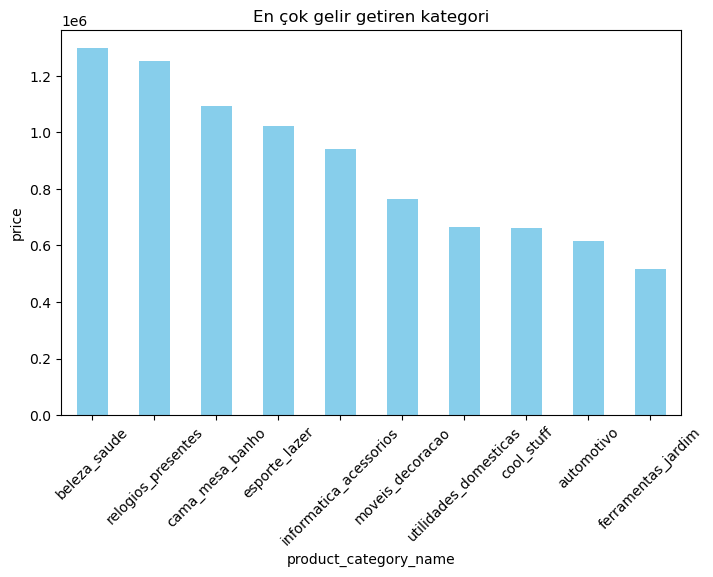

In [33]:
plt.figure(figsize=(8,5))
top_category.head(10).plot(kind= "bar", color= "skyblue")
plt.title( "En çok gelir getiren kategori")
plt.xlabel= ("Kategori")
plt.ylabel( "price")
plt.xticks(rotation=45)
plt.show()

In [35]:
# En çok satılan kategori sorusuna cevap buldum.
df[ "product_category_name"].value_counts()

product_category_name
cama_mesa_banho                                  11823
beleza_saude                                      9972
esporte_lazer                                     8945
moveis_decoracao                                  8744
informatica_acessorios                            8082
                                                 ...  
portateis_cozinha_e_preparadores_de_alimentos       15
cds_dvds_musicais                                   14
pc_gamer                                            10
fashion_roupa_infanto_juvenil                        8
seguros_e_servicos                                   2
Name: count, Length: 74, dtype: int64

**INSIGHT** :Yatak/masa/banyo gibi yüksek hacimli kategorilerde sepet ortalamasını artırmak için ürün paketleme stratejisi uygulanabilir. Güzellik & sağlık gibi yüksek gelir getiren kategorilerde ise kâr marjını koruyacak hedefli kampanyalar planlanabilir.

In [37]:
#En çok harcayan müşteriler sorusuna cevap buldum.
df.groupby( "customer_id")[ "price"].sum().sort_values(ascending=False)

customer_id
1617b1357756262bfa56ab541c47bc16    13440.00
9af2372a1e49340278e7c1ef8d749f34    11383.95
de832e8dbb1f588a47013e53feaa67cc    10856.10
63b964e79dee32a3587651701a2b8dbf     9888.00
6f241d5bbb142b6f764387c8c270645a     9520.14
                                      ...   
5ac9fcc9259df95cf14d27238b112148        2.99
d2c63ad286e3ca9dd69218008d61ff81        2.90
184e8e8e48937145eb96c721ef1f0747        2.29
161b6d415e8b3413c6609c70cf405b5a        0.85
9f9d249355f63c5c1216a82b802452c1        0.85
Name: price, Length: 98665, dtype: float64

In [39]:
# Müşteri başına ortalama harcama.
df.groupby( "customer_id")["price"].sum().mean()

np.float64(144.01373678609437)

In [48]:
#Hangi yöntemi kullanan müşteri daha çok para harcıyor.
payment_analysis=df.groupby( "payment_type")[ "price"].mean().sort_values(ascending=False)
payment_analysis.head(5)

payment_type
credit_card    126.477858
debit_card     108.668681
voucher        105.112152
boleto         104.584146
Name: price, dtype: float64

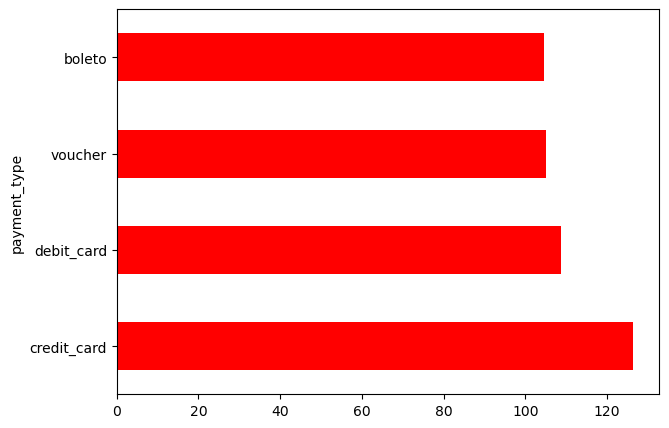

In [49]:
plt.figure(figsize=(7,5))
payment_analysis.head(5).plot(kind= "barh",color= "red")
plt.show()

In [52]:
#Brezilya günlük satış trendi.
df[ "day_name"]=df[ "order_purchase_timestamp"].dt.day_name()
daily_analysis=df.groupby( "day_name")[ "price"].sum().sort_values(ascending=False)
daily_analysis.head(10)

day_name
Monday       2319249.07
Tuesday      2269268.32
Wednesday    2222399.27
Thursday     2125321.85
Friday       2046496.31
Sunday       1654131.60
Saturday     1572248.92
Name: price, dtype: float64

**INSIGHT** : Satışların haftanın başında, özellikle Pazartesi günü zirve yaptığı görülmektedir. Bu durum, kullanıcıların hafta başında alışveriş yapma eğiliminde olduğunu göstermektedir.Bu doğrultuda, Pazartesi günleri hedefli e-posta kampanyaları ve hatırlatma bildirimleri gönderilerek satışlar daha da artırılabilir.

In [54]:
df[ "hour"]=df[ "order_purchase_timestamp"].dt.hour
hour_analysis=df.groupby( "hour")[ "order_id"].count()
hour_analysis.head(10)

hour
0    2894
1    1339
2     611
3     323
4     253
5     225
6     569
7    1419
8    3501
9    5644
Name: order_id, dtype: int64

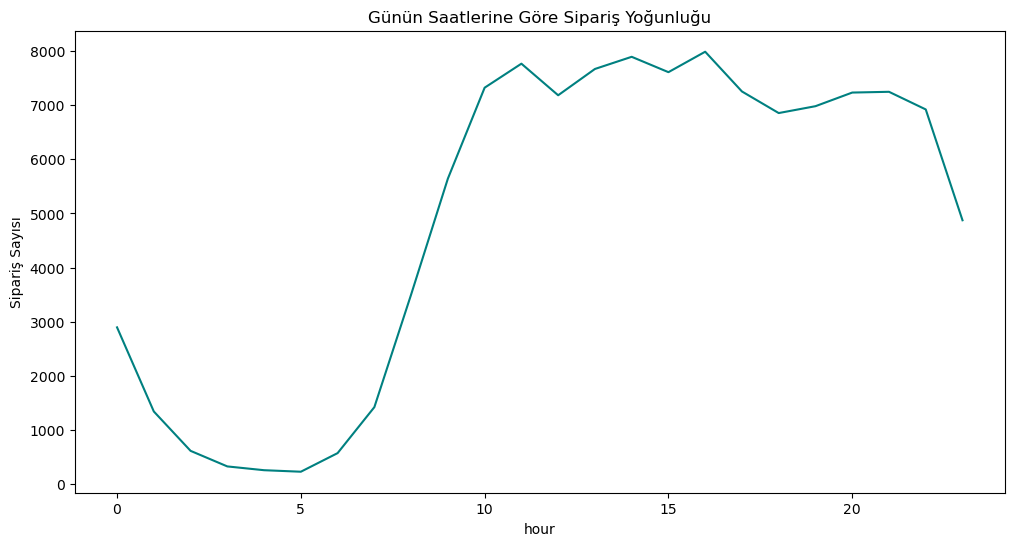

In [59]:
plt.figure(figsize=(12,6))
sns.lineplot(x=hour_analysis.index, y=hour_analysis.values, color='teal')
plt.title('Günün Saatlerine Göre Sipariş Yoğunluğu')
plt.ylabel('Sipariş Sayısı')
plt.show()

**INISHGT** :Siparişlerin gün içerisinde arttığı, özellikle sabah saatlerinden itibaren yükselişe geçerek günün ilerleyen saatlerinde yoğunlaştığı görülmektedir. Gece saatlerinde ise sipariş sayısı oldukça düşüktür.

In [63]:
df["freight_analysis"]=(df[ "freight_value"]/ df[ "price"])*100
freight=df.groupby( "product_category_name")["freight_analysis"].mean().sort_values(ascending=False)
freight.head(10)

product_category_name
casa_conforto_2                   93.114469
dvds_blu_ray                      80.242838
artigos_de_natal                  68.314751
eletronicos                       67.716147
flores                            56.497949
sinalizacao_e_seguranca           54.448858
fashion_underwear_e_moda_praia    53.423979
telefonia                         50.512388
alimentos_bebidas                 49.876117
moveis_colchao_e_estofado         47.019030
Name: freight_analysis, dtype: float64

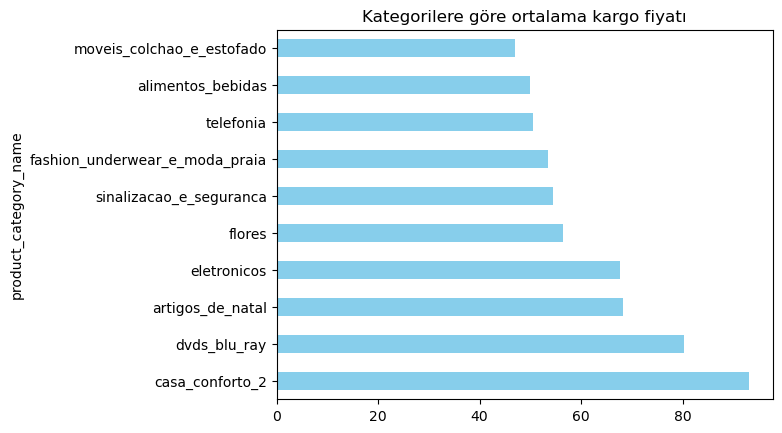

In [64]:
freight.head(10).plot(kind= "barh",color= "skyblue")
plt.title( "Kategorilere göre ortalama kargo fiyatı")
plt.show()

**INISHGT** : casa_conforto_2 kategorisinde kargo ücreti,ürün fiyatının %93'ne ulaşmış.Bu şekide karlılık arttırılamaz , yüksek kargo maliyetli ürünler için X TL üzerine kargo bedava gibi strateji uygulanabilir.